# Thailand Rain-Any Neighbor Models (V1)

Thailand-wide port of `bkk_final_4_rain_any_neighbor_models.ipynb`. Trains the same
best practical 4-model setup, but on the national 25 km grid using precomputed features
from PostgreSQL table `"OM_THAILAND_DATA_PRECOMPUTE"` (built by
`OM_Script/precompute_om_thailand_features.py` from `"OM_Thailand_Data"`).

Models trained:

- `1h`: LightGBM
- `2h`: LightGBM
- `3h`: HistGradientBoosting
- `6h`: HistGradientBoosting

## Differences from the Bangkok notebook

1. **Source table** is `"OM_THAILAND_DATA_PRECOMPUTE"` (833 grids at 25 km) instead of
   `"OM_BKK_DATA_PRECOMPUTE"` (96 grids at 9 km). Feature and target definitions are identical.
2. **Panel truncated at 2026-06-25 23:00.** In `"OM_Thailand_Data"` all 833 grids report
   from 2025-07-20 to 2026-06-25, but only 100 grids continue to 2026-07-19. Keeping the tail
   would make the test split cover a different region than train, so it is dropped.
3. **Memory-safe loading.** ~6.8M rows x 66 features does not fit comfortably as float64.
   Data streams from a server-side cursor into preallocated float32 arrays, and the
   chronological splits are contiguous *views* rather than copies.
4. **HistGradientBoosting early stopping disabled.** Bangkok used the default
   `early_stopping="auto"`, which activates above 10k rows and builds its internal
   validation slice with a random `train_test_split` - future hours leak into the
   stopping decision, and the raw float32 matrix gets copied. The chronological
   validation split from section 6 is the honest holdout, so the 3h/6h models run all
   250 iterations deterministically instead.
5. **Thresholds selected on validation.** The Bangkok notebook hardcodes thresholds tuned
   for Bangkok and also reports the best-F1 threshold on test. Here the operating threshold
   is chosen on the validation split and then evaluated once on test, so the reported
   numbers are not threshold-fitted to the test set. The Bangkok thresholds are still
   reported side by side for comparison.

## 1. Setup

In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_Thailand_Data"'
PRECOMPUTE_TABLE_NAME = '"OM_THAILAND_DATA_PRECOMPUTE"'
PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_thailand_rain_any_final_4_neighbor_models"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)

# Operating thresholds carried over from the Bangkok notebook, kept for comparison only.
BANGKOK_PROBABILITY_THRESHOLDS = {
    1: 0.60,
    2: 0.50,
    3: 0.30,
    6: 0.30,
}
MODEL_PLAN = {
    1: "lightgbm",
    2: "lightgbm",
    3: "hist_gradient_boosting",
    6: "hist_gradient_boosting",
}

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None  # Example for quick smoke tests: 300_000
RANDOM_STATE = 42

## 3. Feature Columns

In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
TARGET_COLUMNS = [f"rain_any_next_{horizon}h" for horizon in HORIZONS]

print(f"Features used: {len(FEATURE_COLUMNS)}")
print(f"Targets: {TARGET_COLUMNS}")

Features used: 66
Targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 4. Load Precomputed Training Data

The Bangkok notebook loads with `pd.read_sql_query` into a float64 DataFrame. At Thailand
scale that is roughly 4 GB before any split copies are made, so this version streams a
server-side cursor into preallocated `float32` arrays sized by an up-front `COUNT(*)`.
Rows arrive ordered by `(local_forecast_time, grid_number)`, which is what makes the
chronological splits in section 6 free.

In [4]:
ROW_FILTER_SQL = f'''
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND rain_any_next_{max(HORIZONS)}h IS NOT NULL
      AND neighbor_count > 0
'''


def connect():
    return psycopg2.connect(**DB_CONFIG)


def count_training_rows(conn):
    with conn.cursor() as cur:
        cur.execute(f"SELECT count(*) FROM {PRECOMPUTE_TABLE_NAME} {ROW_FILTER_SQL}")
        return cur.fetchone()[0]


def read_training_data(sample_rows=None, batch_size=250_000):
    """Stream the training panel into preallocated float32 / int8 arrays.

    Returns (x, y, forecast_time, grid_number). Feature and target casting happens
    server-side so psycopg2 never materialises a float64 Python object per cell.
    """
    # COALESCE to NaN: psycopg2 hands back None for SQL NULL, which cannot be cast
    # into a float32 array. Both LightGBM and HistGradientBoosting handle NaN natively.
    feature_sql = ",\n        ".join(
        f"COALESCE({c}::real, 'NaN'::real) AS {c}" for c in FEATURE_COLUMNS
    )
    target_sql = ",\n        ".join(f"{t}::smallint" for t in TARGET_COLUMNS)
    query = f'''
    SELECT
        grid_number,
        local_forecast_time,
        {feature_sql},
        {target_sql}
    FROM {PRECOMPUTE_TABLE_NAME}
    {ROW_FILTER_SQL}
    ORDER BY local_forecast_time, grid_number
    '''

    with connect() as conn:
        total_rows = count_training_rows(conn)
        n_rows = min(total_rows, sample_rows) if sample_rows else total_rows
        if sample_rows:
            query += f"\n    LIMIT {int(sample_rows)}"
        print(f"Allocating {n_rows:,} rows x {len(FEATURE_COLUMNS)} features "
              f"({n_rows * len(FEATURE_COLUMNS) * 4 / 1e9:.2f} GB float32)")

        x = np.empty((n_rows, len(FEATURE_COLUMNS)), dtype="float32")
        y = np.empty((n_rows, len(TARGET_COLUMNS)), dtype="int8")
        forecast_time = np.empty(n_rows, dtype="datetime64[s]")
        grid_number = np.empty(n_rows, dtype="int32")

        n_feat = len(FEATURE_COLUMNS)
        filled = 0
        with conn.cursor(name="thailand_training_stream") as cur:
            cur.itersize = batch_size
            cur.execute(query)
            while filled < n_rows:
                batch = cur.fetchmany(batch_size)
                if not batch:
                    break
                block = np.asarray(batch, dtype="object")
                take = min(len(batch), n_rows - filled)
                grid_number[filled:filled + take] = block[:take, 0].astype("int32")
                forecast_time[filled:filled + take] = block[:take, 1].astype("datetime64[s]")
                x[filled:filled + take] = block[:take, 2:2 + n_feat].astype("float32")
                y[filled:filled + take] = block[:take, 2 + n_feat:].astype("int8")
                filled += take
                print(f"  loaded {filled:,} / {n_rows:,}", end="\r", flush=True)
        print()

    if filled != n_rows:
        x, y = x[:filled], y[:filled]
        forecast_time, grid_number = forecast_time[:filled], grid_number[:filled]
    return x, y, forecast_time, grid_number

In [5]:
x_all, y_all, forecast_time, grid_number = read_training_data(SAMPLE_ROWS)

print(f"x: {x_all.shape}  y: {y_all.shape}")
print(f"{forecast_time.min()} to {forecast_time.max()}")
print(f"grids: {np.unique(grid_number).size}")
print(f"x memory: {x_all.nbytes / 1e9:.2f} GB")

nan_counts = np.isnan(x_all).sum(axis=0)
if nan_counts.any():
    display(pd.Series(nan_counts, index=FEATURE_COLUMNS).loc[lambda s: s > 0].sort_values(ascending=False))
else:
    print("No NaNs in feature matrix.")

display(pd.DataFrame(x_all[:5], columns=FEATURE_COLUMNS).assign(
    grid_number=grid_number[:5], forecast_time=forecast_time[:5]))

Allocating 6,808,840 rows x 66 features (1.80 GB float32)



x: (6808840, 66)  y: (6808840, 4)
2025-07-20T06:00:00 to 2026-06-25T22:00:00
grids: 833
x memory: 1.80 GB


No NaNs in feature matrix.


,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,temperature_dew_point_spread,pressure_msl_change_3h,pressure_msl_change_6h,precipitation_lag_1h,precipitation_lag_2h,precipitation_lag_3h,precipitation_lag_6h,precipitation_sum_past_3h,precipitation_sum_past_6h,precipitation_sum_past_12h,precipitation_sum_past_24h,cloud_cover_lag_1h,cloud_cover_lag_3h,cloud_cover_lag_6h,humidity_lag_1h,humidity_lag_3h,humidity_lag_6h,wind_speed_lag_1h,wind_speed_lag_3h,hour_sin,hour_cos,month_sin,month_cos,grid_row,grid_column,latitude,longitude,neighbor_count,neighbor_precipitation_mean,neighbor_precipitation_max,neighbor_precipitation_sum,neighbor_rain_count,neighbor_rain_rate,neighbor_cloud_cover_mean,neighbor_cloud_cover_max,neighbor_relative_humidity_mean,neighbor_relative_humidity_max,neighbor_pressure_msl_mean,neighbor_pressure_msl_min,neighbor_pressure_msl_max,neighbor_temperature_2m_mean,neighbor_dew_point_2m_mean,neighbor_temperature_dew_point_spread_mean,neighbor_wind_speed_10m_mean,neighbor_wind_speed_10m_max,row_minus_precipitation_mean,row_plus_precipitation_mean,column_minus_precipitation_mean,column_plus_precipitation_mean,row_minus_cloud_cover_mean,row_plus_cloud_cover_mean,column_minus_cloud_cover_mean,column_plus_cloud_cover_mean,neighbor_precipitation_mean_minus_center,neighbor_cloud_cover_mean_minus_center,neighbor_relative_humidity_mean_minus_center,center_pressure_msl_minus_neighbor_mean,grid_number,forecast_time
0,23.3000,76.0000,1007.6000,943.2000,18.9000,0.0000,100.0000,0.6000,342.0000,4.4000,0.1000,-0.6000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,78.0000,75.0000,75.0000,0.9000,2.7000,1.0000,0.0000,-0.5000,-0.8660,2.0000,17.0000,5.8393,101.0303,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,81.5000,93.0000,1007.1500,1006.7000,1007.6000,21.9500,18.5000,3.4500,5.8000,8.1000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,100.0000,0.0000,0.0000,5.5000,0.4500,1,2025-07-20 06:00:00
1,20.8000,70.0000,1007.6000,920.5000,15.1000,0.0000,100.0000,8.1000,179.0000,5.7000,0.1000,-0.7000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,70.0000,76.0000,76.0000,8.0000,6.1000,1.0000,0.0000,-0.5000,-0.8660,2.0000,18.0000,5.8393,101.2608,3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,79.0000,93.0000,1007.2667,1006.7000,1007.6000,22.7000,18.7667,3.9333,2.4333,3.5000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,100.0000,0.0000,0.0000,9.0000,0.3333,2,2025-07-20 06:00:00
2,21.4000,92.0000,1006.4000,985.8000,20.1000,0.0000,100.0000,4.5000,230.0000,1.3000,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,92.0000,97.0000,96.0000,3.7000,2.1000,1.0000,0.0000,-0.5000,-0.8660,2.0000,20.0000,5.8393,101.7219,3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,87.6667,100.0000,1006.5333,1005.8000,1007.5000,23.2333,20.8667,2.3667,2.0000,3.2000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,100.0000,0.0000,0.0000,-4.3333,-0.1333,3,2025-07-20 06:00:00
3,23.1000,93.0000,1006.7000,966.0000,21.9000,0.0000,100.0000,3.5000,219.0000,1.2000,0.0000,-0.9000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,89.0000,91.0000,96.0000,3.2000,3.0000,1.0000,0.0000,-0.5000,-0.8660,3.0000,18.0000,6.0654,101.2608,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,79.5000,94.0000,1006.9833,1006.1000,1007.6000,23.2833,19.4500,3.8333,4.5667,8.5000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,100.0000,0.0000,0.0000,-13.5000,-0.2833,4,2025-07-20 06:00:00
4,21.7000,68.0000,1007.5000,913.6000,15.5000,0.0000,100.0000,3.2000,214.0000,6.2000,0.0000,-0.9000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,100.0000,100.0000,68.0000,71.0000,80.0000,3.1000,2.4000,1.0000,0.0000,-0.5000,-0.8660,3.0000,19.0000,6.0654,101.4914,7.0000,0.0000,0.0000,0.0000,0

## 5. Target Balance

,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_any_next_1h,0.1000,6808840,1524270,0.2239
1,2,rain_any_next_2h,0.1000,6808840,1918528,0.2818
2,3,rain_any_next_3h,0.1000,6808840,2217421,0.3257
3,6,rain_any_next_6h,0.1000,6808840,2863031,0.4205


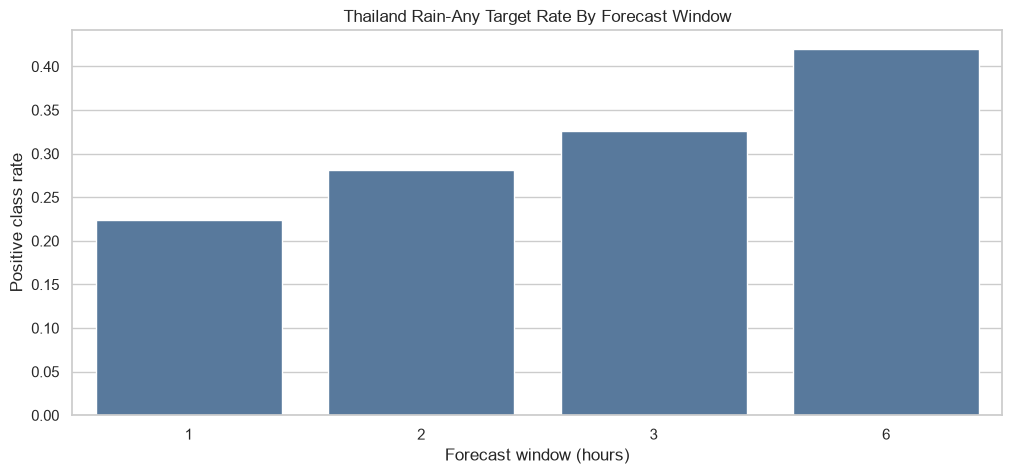

In [6]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_any_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": int(y_all.shape[0]),
        "rain_rows": int(y_all[:, i].sum()),
        "rain_rate": float(y_all[:, i].mean()),
    }
    for i, horizon in enumerate(HORIZONS)
])
display(target_balance)

sns.barplot(data=target_balance, x="horizon_h", y="rain_rate", color="#4c78a8")
plt.title("Thailand Rain-Any Target Rate By Forecast Window")
plt.xlabel("Forecast window (hours)")
plt.ylabel("Positive class rate")
plt.show()

## 6. Chronological Split

Rows are already ordered by `local_forecast_time`, so each split is a contiguous slice.
`np.searchsorted` finds the boundaries and the splits are numpy **views** - no data is copied.

In [7]:
def time_split_bounds(times, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.unique(times)
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    train_stop = int(np.searchsorted(times, train_end, side="left"))
    validation_stop = int(np.searchsorted(times, validation_end, side="left"))
    return train_end, validation_end, train_stop, validation_stop


train_end, validation_end, train_stop, validation_stop = time_split_bounds(
    forecast_time, TRAIN_FRACTION, VALIDATION_FRACTION
)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")

x_train, x_validation, x_test = x_all[:train_stop], x_all[train_stop:validation_stop], x_all[validation_stop:]
y_train_all, y_validation_all, y_test_all = y_all[:train_stop], y_all[train_stop:validation_stop], y_all[validation_stop:]

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(x_train),
     "from": str(forecast_time[:train_stop].min()), "to": str(forecast_time[:train_stop].max())},
    {"split": "validation", "rows": len(x_validation),
     "from": str(forecast_time[train_stop:validation_stop].min()), "to": str(forecast_time[train_stop:validation_stop].max())},
    {"split": "test", "rows": len(x_test),
     "from": str(forecast_time[validation_stop:].min()), "to": str(forecast_time[validation_stop:].max())},
])
display(split_summary)
print(f"splits are zero-copy views: {x_train.base is x_all and x_test.base is x_all}")

Train before: 2026-03-15T17:00:00
Validation before: 2026-05-05T20:00:00


,split,rows,from,to
0,train,4767259,2025-07-20T06:00:00,2026-03-15T16:00:00
1,validation,1022091,2026-03-15T17:00:00,2026-05-05T19:00:00
2,test,1019490,2026-05-05T20:00:00,2026-06-25T22:00:00


splits are zero-copy views: True


## 7. Evaluation Helpers

In [8]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)


def evaluate_probabilities(y_true, probabilities, model_name, horizon, split):
    base = {
        "model": model_name,
        "feature_set": "neighbor_grid",
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df


def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(["model", "horizon_h", "split", "f1"], ascending=[True, True, True, False])
        .groupby(["model", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "horizon_h", "split"])
    )


def metrics_at_thresholds(threshold_results, chosen_thresholds, split="test"):
    """Look up metrics at a given operating threshold per horizon."""
    rows = []
    for horizon, threshold in chosen_thresholds.items():
        selected = threshold_results[
            (threshold_results["horizon_h"] == horizon)
            & (threshold_results["model"] == MODEL_PLAN[horizon])
            & (threshold_results["split"] == split)
            & (threshold_results["probability_threshold"].round(10) == round(threshold, 10))
        ]
        rows.append(selected)
    return pd.concat(rows, ignore_index=True)

## 8. Train Final 4 Models

In [9]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

import time

models = {}
metric_rows = []
threshold_tables = []
feature_importance_rows = []
train_timings = {}

for index, horizon in enumerate(HORIZONS):
    model_name = MODEL_PLAN[horizon]
    target = f"rain_any_next_{horizon}h"
    print(f"Training {model_name} for {target}...", flush=True)
    started = time.time()

    y_train = y_train_all[:, index]
    y_validation = y_validation_all[:, index]
    y_test = y_test_all[:, index]

    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(
            x_train,
            y_train,
            # LightGBM 4.7 deprecated the eval_set=[(X, y)] form used in the Bangkok
            # notebook in favour of separate eval_X / eval_y arguments.
            eval_X=x_validation,
            eval_y=y_validation,
            eval_metric="binary_logloss",
        )
        for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_):
            feature_importance_rows.append({
                "model": model_name,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
                "is_neighbor_feature": feature in NEIGHBOR_FEATURE_COLUMNS,
            })
    elif model_name == "hist_gradient_boosting":
        model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
            # Bangkok used the default early_stopping="auto", which turns itself on above
            # 10k rows and carves out its validation slice with a *random* train_test_split.
            # On an hourly panel that samples future hours into the stopping criterion, and
            # it copies the raw float32 matrix (~1.3 GB at Thailand scale). Section 6 already
            # holds out a chronological validation split, so stop deterministically instead.
            early_stopping=False,
        )
        model.fit(x_train, y_train)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    models[horizon] = model
    train_timings[horizon] = time.time() - started
    print(f"  fitted in {train_timings[horizon] / 60:.1f} min", flush=True)

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(y_split, probabilities, model_name, horizon, split_name)
        metric_rows.append(metrics)
        threshold_tables.append(thresholds)

all_metrics = pd.DataFrame(metric_rows)
all_threshold_results = pd.concat(threshold_tables, ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)

display(all_metrics.sort_values(["horizon_h", "split"]))

Training lightgbm for rain_any_next_1h...


  fitted in 2.3 min


Training lightgbm for rain_any_next_2h...


  fitted in 3.0 min


Training hist_gradient_boosting for rain_any_next_3h...


  fitted in 1.7 min


Training hist_gradient_boosting for rain_any_next_6h...


  fitted in 1.7 min


,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,lightgbm,neighbor_grid,1,test,1019490,0.3739,0.9142,0.8732,0.1414
0,lightgbm,neighbor_grid,1,validation,1022091,0.0788,0.9427,0.6332,0.0612
3,lightgbm,neighbor_grid,2,test,1019490,0.4657,0.8917,0.8848,0.1513
2,lightgbm,neighbor_grid,2,validation,1022091,0.1163,0.9201,0.6498,0.0808
5,hist_gradient_boosting,neighbor_grid,3,test,1019490,0.5343,0.8791,0.8971,0.1410
4,hist_gradient_boosting,neighbor_grid,3,validation,1022091,0.1478,0.9039,0.6595,0.0793
7,hist_gradient_boosting,neighbor_grid,6,test,1019490,0.6784,0.8620,0.9296,0.1407
6,hist_gradient_boosting,neighbor_grid,6,validation,1022091,0.2246,0.8836,0.7061,0.1103


## 8b. Operating Threshold Selection

The threshold is picked on **validation** by best F1, then applied to **test**. This avoids
reporting a threshold that was fitted on the same rows it is scored on.

In [10]:
validation_best = best_by_f1[best_by_f1["split"] == "validation"]
SELECTED_PROBABILITY_THRESHOLDS = {
    int(row.horizon_h): float(row.probability_threshold)
    for row in validation_best.itertuples()
}
print("Selected on validation:", SELECTED_PROBABILITY_THRESHOLDS)
print("Bangkok notebook values:", BANGKOK_PROBABILITY_THRESHOLDS)

selected_threshold_metrics = metrics_at_thresholds(
    all_threshold_results, SELECTED_PROBABILITY_THRESHOLDS, split="test")
bangkok_threshold_metrics = metrics_at_thresholds(
    all_threshold_results, BANGKOK_PROBABILITY_THRESHOLDS, split="test")

report_columns = [
    "horizon_h", "model", "probability_threshold", "rain_rate", "predicted_rain_rate",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier_score",
    "true_positives", "false_positives", "false_negatives", "true_negatives",
]

print("\nTEST metrics at validation-selected thresholds")
display(selected_threshold_metrics[report_columns].sort_values("horizon_h"))

print("\nTEST metrics at Bangkok thresholds (comparison)")
display(bangkok_threshold_metrics[report_columns].sort_values("horizon_h"))

print("\nTEST oracle best-F1 thresholds (upper bound, fitted on test - do not deploy)")
display(best_by_f1[best_by_f1["split"] == "test"][report_columns].sort_values("horizon_h"))

Selected on validation: {3: 0.40000000000000013, 6: 0.40000000000000013, 1: 0.6500000000000001, 2: 0.6000000000000002}
Bangkok notebook values: {1: 0.6, 2: 0.5, 3: 0.3, 6: 0.3}

TEST metrics at validation-selected thresholds


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
2,1,lightgbm,0.6500,0.3739,0.4225,0.8305,0.7419,0.8382,0.7871,0.9142,0.8732,0.1414,319553,111164,61666,527107
3,2,lightgbm,0.6000,0.4657,0.5298,0.7990,0.7498,0.8531,0.7981,0.8917,0.8848,0.1513,405020,135136,69762,409572
0,3,hist_gradient_boosting,0.4000,0.5343,0.5854,0.7928,0.7795,0.8539,0.8150,0.8791,0.8971,0.1410,465152,131608,79595,343135
1,6,hist_gradient_boosting,0.4000,0.6784,0.7267,0.7983,0.8280,0.8870,0.8565,0.8620,0.9296,0.1407,613460,127451,78159,200420



TEST metrics at Bangkok thresholds (comparison)


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
0,1,lightgbm,0.6000,0.3739,0.4525,0.8203,0.7146,0.8647,0.7825,0.9142,0.8732,0.1414,329655,131641,51564,506630
1,2,lightgbm,0.5000,0.4657,0.5936,0.7787,0.7059,0.8997,0.7911,0.8917,0.8848,0.1513,427142,177984,47640,366724
2,3,hist_gradient_boosting,0.3000,0.5343,0.6550,0.7756,0.7366,0.9029,0.8113,0.8791,0.8971,0.1410,491842,175876,52905,298867
3,6,hist_gradient_boosting,0.3000,0.6784,0.7972,0.7864,0.7915,0.9301,0.8552,0.8620,0.9296,0.1407,643264,169442,48355,158429



TEST oracle best-F1 thresholds (upper bound, fitted on test - do not deploy)


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
29,1,lightgbm,0.7000,0.3739,0.3909,0.8376,0.7706,0.8056,0.7877,0.9142,0.8732,0.1414,307109,91416,74110,546855
61,2,lightgbm,0.6000,0.4657,0.5298,0.7990,0.7498,0.8531,0.7981,0.8917,0.8848,0.1513,405020,135136,69762,409572
91,3,hist_gradient_boosting,0.4000,0.5343,0.5854,0.7928,0.7795,0.8539,0.8150,0.8791,0.8971,0.1410,465152,131608,79595,343135
124,6,hist_gradient_boosting,0.3500,0.6784,0.7601,0.7942,0.8109,0.9085,0.8570,0.8620,0.9296,0.1407,628370,146528,63249,181343


## 9. Results Charts

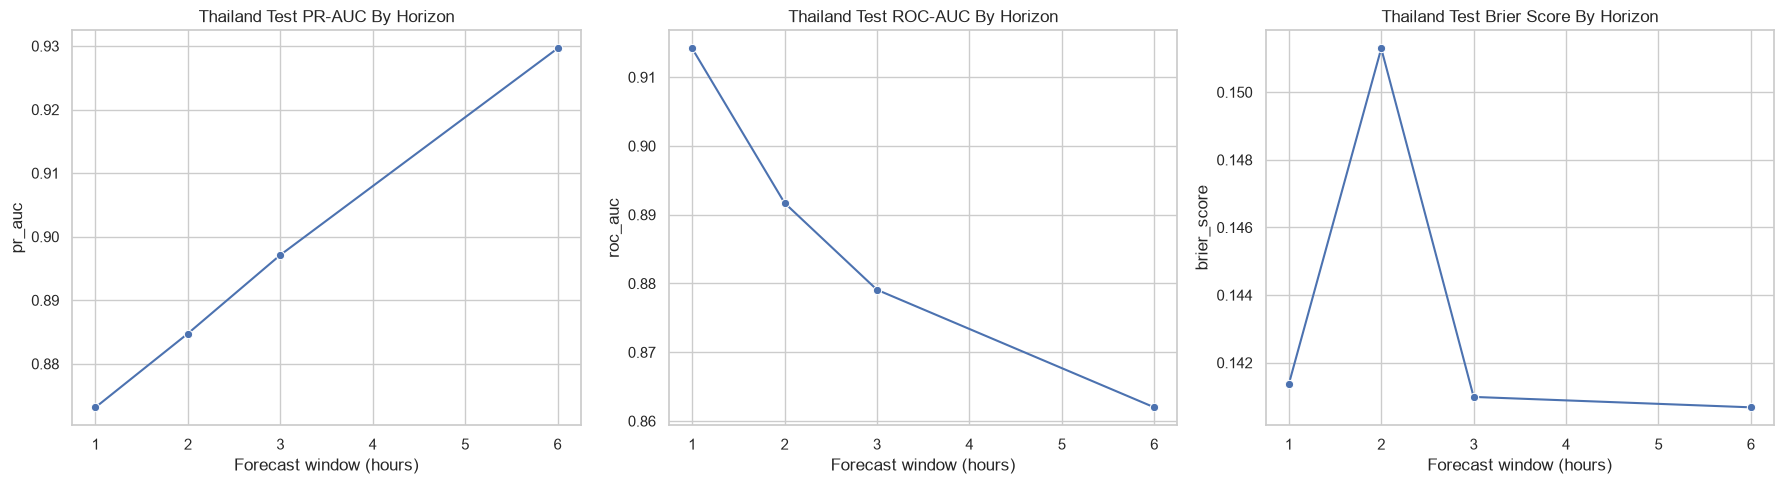

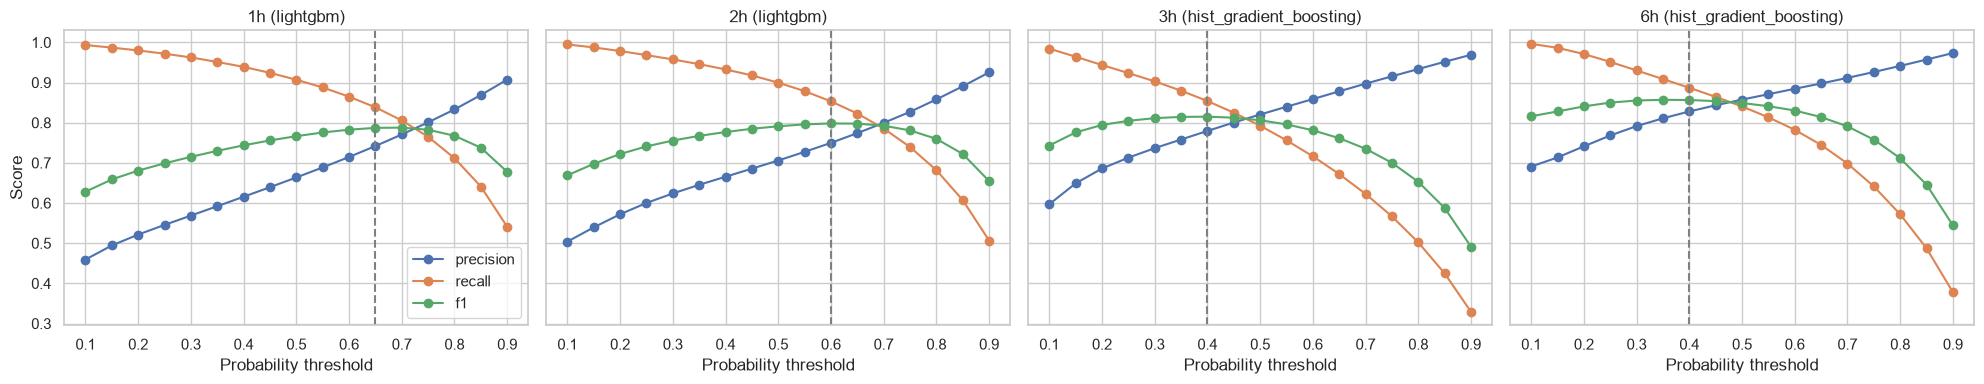

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
test_metrics = all_metrics[all_metrics["split"] == "test"]
sns.lineplot(data=test_metrics, x="horizon_h", y="pr_auc", marker="o", ax=axes[0])
axes[0].set_title("Thailand Test PR-AUC By Horizon")
sns.lineplot(data=test_metrics, x="horizon_h", y="roc_auc", marker="o", ax=axes[1])
axes[1].set_title("Thailand Test ROC-AUC By Horizon")
sns.lineplot(data=test_metrics, x="horizon_h", y="brier_score", marker="o", ax=axes[2])
axes[2].set_title("Thailand Test Brier Score By Horizon")
for ax in axes:
    ax.set_xlabel("Forecast window (hours)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(20, 4), sharey=True)
for ax, horizon in zip(axes, HORIZONS):
    subset = all_threshold_results[
        (all_threshold_results["horizon_h"] == horizon)
        & (all_threshold_results["split"] == "test")
    ]
    ax.plot(subset["probability_threshold"], subset["precision"], marker="o", label="precision")
    ax.plot(subset["probability_threshold"], subset["recall"], marker="o", label="recall")
    ax.plot(subset["probability_threshold"], subset["f1"], marker="o", label="f1")
    ax.axvline(SELECTED_PROBABILITY_THRESHOLDS[horizon], color="grey", linestyle="--")
    ax.set_title(f"{horizon}h ({MODEL_PLAN[horizon]})")
    ax.set_xlabel("Probability threshold")
axes[0].set_ylabel("Score")
axes[0].legend()
plt.tight_layout()
plt.show()

,model,horizon_h,feature,importance,is_neighbor_feature
29,lightgbm,1,hour_cos,1962.0000,False
28,lightgbm,1,hour_sin,1456.0000,False
4,lightgbm,1,dew_point_2m,1203.0000,False
32,lightgbm,1,grid_row,1183.0000,False
6,lightgbm,1,cloud_cover,983.0000,False
3,lightgbm,1,surface_pressure,971.0000,False
11,lightgbm,1,pressure_msl_change_6h,944.0000,False
31,lightgbm,1,month_cos,846.0000,False
50,lightgbm,1,neighbor_dew_point_2m_mean,832.0000,True
33,lightgbm,1,grid_column,824.0000,False


Share of LightGBM split importance coming from neighbour-grid features


is_neighbor_feature,False,True,neighbor_importance_share
horizon_h,,,
1,20877.0000,10123.0000,0.3265
2,21236.0000,9764.0000,0.3150


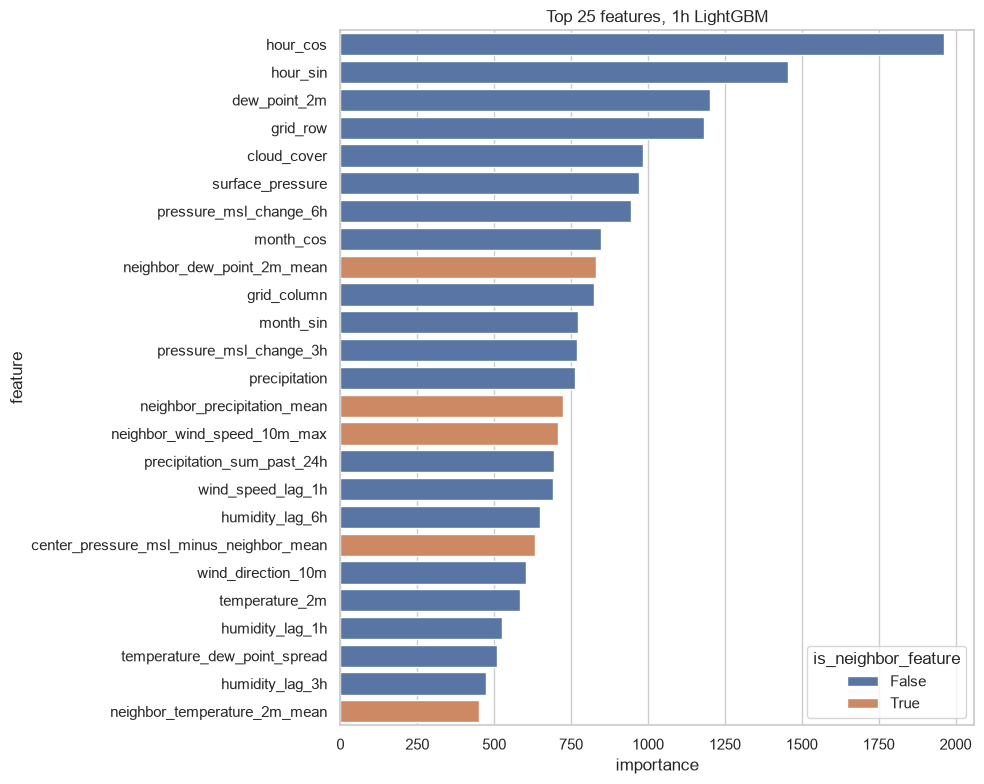

In [12]:
feature_importance = pd.DataFrame(feature_importance_rows)
if not feature_importance.empty:
    top_importance = (
        feature_importance.sort_values(["horizon_h", "importance"], ascending=[True, False])
        .groupby("horizon_h").head(20)
    )
    display(top_importance)

    neighbor_share = (
        feature_importance.groupby(["horizon_h", "is_neighbor_feature"])["importance"].sum()
        .unstack(fill_value=0.0)
        .reindex(columns=[False, True], fill_value=0.0)
    )
    neighbor_share["neighbor_importance_share"] = (
        neighbor_share[True] / neighbor_share.sum(axis=1)
    )
    print("Share of LightGBM split importance coming from neighbour-grid features")
    display(neighbor_share)

    fig, ax = plt.subplots(figsize=(10, 8))
    top_1h = feature_importance[feature_importance["horizon_h"] == 1].nlargest(25, "importance")
    sns.barplot(data=top_1h, y="feature", x="importance",
                hue="is_neighbor_feature", dodge=False, ax=ax)
    ax.set_title("Top 25 features, 1h LightGBM")
    plt.tight_layout()
    plt.show()

## 10. Save Final Models And Results

In [13]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in models.items():
    model_name = MODEL_PLAN[horizon]
    threshold = SELECTED_PROBABILITY_THRESHOLDS[horizon]
    path = MODEL_DIR / (
        f"om_thailand_rain_any_next_{horizon}h_neighbor_grid_{model_name}"
        f"_prob_threshold_{threshold:g}_rain_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    )
    joblib.dump(model, path)

target_balance.to_csv(MODEL_DIR / "final_4_target_balance.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "final_4_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "final_4_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "final_4_best_thresholds_by_f1.csv", index=False)
selected_threshold_metrics.to_csv(MODEL_DIR / "final_4_selected_threshold_metrics.csv", index=False)
bangkok_threshold_metrics.to_csv(MODEL_DIR / "final_4_bangkok_threshold_metrics.csv", index=False)
if not feature_importance.empty:
    feature_importance.to_csv(MODEL_DIR / "final_4_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "region": "thailand_25km_grid",
    "target_type": "rain_any_within_next_n_hours",
    "model_plan": MODEL_PLAN,
    "selected_probability_thresholds": SELECTED_PROBABILITY_THRESHOLDS,
    "bangkok_probability_thresholds": BANGKOK_PROBABILITY_THRESHOLDS,
    "threshold_selection": "best F1 on validation split, evaluated once on test",
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_columns": FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "panel_end_note": "source truncated at 2026-06-25 23:00 so all 833 grids are present throughout",
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "rows": int(x_all.shape[0]),
    "grids": int(np.unique(grid_number).size),
    "train_seconds": train_timings,
    "sample_rows": SAMPLE_ROWS,
    "model_dir": str(MODEL_DIR),
    "target_balance": target_balance.to_dict(orient="records"),
    "metrics": all_metrics.to_dict(orient="records"),
    "best_thresholds_by_f1": best_by_f1.to_dict(orient="records"),
    "selected_threshold_metrics": selected_threshold_metrics.to_dict(orient="records"),
}
(MODEL_DIR / "final_4_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved final 4 models and result CSVs to {MODEL_DIR}")

Saved final 4 models and result CSVs to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_thailand_rain_any_final_4_neighbor_models
